# Escape from Flatland — does the patent record actually show it?

In 2009 Lovering, Bikker and Humblet published *Escape from Flatland: Increasing Saturation
as an Approach to Improving Clinical Success* (J. Med. Chem. 52(21), 6752–6756,
[10.1021/jm901241e](https://doi.org/10.1021/jm901241e)). The argument, roughly: med-chem had
drifted toward flat, aromatic, sp2-heavy molecules because they're easy to make (Suzuki
couplings everywhere), and the more saturated / three-dimensional compounds were the ones
that survived further down the clinical pipeline. They proposed **Fsp3** — the fraction of
carbons that are sp3-hybridised — as a cheap one-number proxy for 3D-ness. Lovering came back
to it in 2013 (*Escape from Flatland 2*, Med. Chem. Commun. 4, 515) after the phrase had
already become a slogan.

It's a paper people cite a lot. What I want to know is whether it left a fingerprint on what
industry actually *did*, and what that costs on the bench.

**Data:** 
1. Alvarado, Johnston & Brown, *Pharmaceutical manufacturing open datasets for machine
learning in the primary and secondary domains* (CMAC, University of Strathclyde; SSRN 6394198).
Two NLP-extracted sets from patent text — ~385K primary (drug substance) procedures and ~9.2K
secondary (drug product) records, with operations, materials and conditions broken out per step.
2. For some reason I was unable to get the US PTO API working. Instead I used multiple sources
to collate the first registered patent no. from each year since the 1970s. This gives us a
collated patent number to year mapping, which is a relative time-frame to carry out this time
series analytics. A more nuanced research is possible, but it would require the US PTO API to
work as intended.


**Three questions I am trying to answer:**

1. Did Fsp3 rise over the ~1976–2021 window, and is there anything at 2009?
2. If molecules got more 3D, did that cost anything — lower yields, more elaborate routes?
3. How much of any trend is real chemistry versus an artefact of how the text was extracted?

**One callout:** this is patent chemistry, which is not the same population as clinical
candidates. Lovering's claim was about compounds that *succeed clinically*. Nothing here can
speak to that.

## 1. Load

Five tables for primary manufacturing, five for secondary, plus the patent-number → year
crosswalk. The primary set is the one I need — `procedures` is the grain (one row per
synthesis procedure), and `operations` / `op_materials` / `op_conditions` hang off it.

I'm loading the secondary tables too even though this notebook doesn't touch them, mostly so
the row counts print and I can sanity-check against the paper's stated 385K / 9.2K. If those
don't match, something's wrong with my copy of the data before I've written a line of analysis.


In [2]:
import pandas as pd
import numpy as np
import ast
import os

# Set display options for better inspection
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

data_dir = './Data'

# 1. Primary Manufacturing (PM) Data
procedures = pd.read_csv(f'{data_dir}/procedures.csv')
operations = pd.read_csv(f'{data_dir}/operations.csv')
op_materials = pd.read_csv(f'{data_dir}/op_materials.csv')
op_conditions = pd.read_csv(f'{data_dir}/op_conditions.csv')
materials_reference = pd.read_csv(f'{data_dir}/materials_reference.csv')

# 2. Secondary Manufacturing (SM) Data
sm_procedures = pd.read_csv(f'{data_dir}/sm_procedures.csv')
sm_apis = pd.read_csv(f'{data_dir}/sm_apis.csv')
sm_operations = pd.read_csv(f'{data_dir}/sm_operations.csv')
sm_op_materials = pd.read_csv(f'{data_dir}/sm_op_materials.csv')
sm_op_conditions = pd.read_csv(f'{data_dir}/sm_op_conditions.csv')

# 3. Patent Timeline Crosswalk
# Note: Ensure you have 'openpyxl' installed to read .xlsx files
crosswalk = pd.read_excel(f'{data_dir}/patent_number_year_crosswalk.xlsx', sheet_name='crosswalk')

# Quick validation check
print(f"Loaded {len(procedures)} PM procedures and {len(sm_procedures)} SM procedures.")

Loaded 385293 PM procedures and 9216 SM procedures.


## 2. Build a complexity score (and throw out the stubs)

There's no "how hard was this to make" column, so we'll have to construct one. The approach here
is TF-IDF borrowed wholesale from text retrieval (Spärck Jones, 1972) — treat each procedure
as a document and each action / condition / material as a term. Something that shows up in
almost every patent (`stir`, `add`, dichloromethane) carries almost no information; something
that shows up in a handful does. IDF weights exactly that way, so summing IDF over a
procedure's distinct actions gives a score that rewards *unusual* chemistry rather than just
*long* chemistry.

We'll compute IDF at the **patent** level, not the procedure level, deliberately. One patent
often contains dozens of near-identical procedures, and if we counted documents as procedures,
a technique that appears 40 times inside one filing would look 40× more common than it is.

Three channels of complexity are being considered here - (actions, conditions, materials),
each min-max normalised before summing so one channel can't dominate on scale alone.

**Known weak spot:** the paper reports extraction quality per entity type, and MATERIALS is
the worst of them (~91.5% F1, 88.2% recall) against OPERATIONS at ~98.2% F1. So `mat_score`
is the noisiest of the three, and it happens to be the largest in magnitude. Worth remembering
when the Fsp3-vs-complexity correlation comes out weak later — some of that is measurement noise.

**Stub filter.** Plenty of "procedures" are extraction artefacts — a sentence fragment that
parsed into 1–2 operations with no materials and no conditions. Instead of being short or
trivial reactions, they're failures to parse, and leaving them in would drag every mean down.
Dropping anything with ≤2 operations *and* zero real materials *and* zero conditions.

**Yields.** `yield_percentage` arrives as a stringified list (multiple yields reported in one
procedure), so `ast.literal_eval` and take the max — the convention being that the headline
yield is the one for the titular product. Anything >100% is chemically impossible and gets
dropped rather than clipped; a 340% yield means the parser grabbed the wrong number, and
clipping it to 100 would smuggle a bad record in as a good one.


In [3]:
print("1. Merging IDs across tables...")
# Attach procedure_id to conditions and materials
op_conds_merged = op_conditions.merge(operations[['op_id', 'procedure_id']], on='op_id', how='left')
op_mats_merged = op_materials.merge(operations[['op_id', 'procedure_id']], on='op_id', how='left')

# Attach patent_number to operations, conditions, and materials
ops_with_patent = operations.merge(procedures[['procedure_id', 'patent_number']], on='procedure_id', how='left')
op_conds_merged = op_conds_merged.merge(procedures[['procedure_id', 'patent_number']], on='procedure_id', how='left')
op_mats_merged = op_mats_merged.merge(procedures[['procedure_id', 'patent_number']], on='procedure_id', how='left')

print("2. Calculating patent-level complexity scores...")
N_patents = procedures['patent_number'].nunique()

def compute_idf_patent_level(df, item_col, N_patents):
    df_counts = df[['patent_number', item_col]].dropna(subset=[item_col]).drop_duplicates().groupby(item_col)['patent_number'].nunique()
    return np.log((N_patents + 1) / (1 + df_counts)) + 1

def procedure_channel_score(df, id_col, item_col, idf_series):
    merged = df[[id_col, item_col]].dropna(subset=[item_col]).drop_duplicates().merge(idf_series.rename('idf'), left_on=item_col, right_index=True, how='left')
    return merged.groupby(id_col)['idf'].sum()

# Score channels
action_idf = compute_idf_patent_level(ops_with_patent, 'op_std_action', N_patents)
action_score = procedure_channel_score(ops_with_patent, 'procedure_id', 'op_std_action', action_idf)

cond_idf = compute_idf_patent_level(op_conds_merged, 'cond_parameter', N_patents)
cond_score = procedure_channel_score(op_conds_merged, 'procedure_id', 'cond_parameter', cond_idf)

real_mats = op_mats_merged[op_mats_merged['mat_type'].isin(['REACTANT', 'SOLVENT'])]
mat_idf = compute_idf_patent_level(real_mats, 'mat_name', N_patents)
mat_score = procedure_channel_score(real_mats, 'procedure_id', 'mat_name', mat_idf)

# Combine and normalize
scores = pd.DataFrame({'action_score': action_score, 'cond_score': cond_score, 'mat_score': mat_score}).fillna(0)
scores['complexity_score'] = ((scores - scores.min()) / (scores.max() - scores.min())).sum(axis=1)

print("3. Filtering out stub procedures...")
op_counts = operations.groupby('procedure_id')['op_id'].count().rename('n_operations')
real_mat_counts = real_mats.groupby('procedure_id')['mat_id'].count().rename('n_real_materials')
cond_counts = op_conds_merged.groupby('procedure_id')['cond_id'].count().rename('n_conditions')

completeness = pd.concat([op_counts, real_mat_counts, cond_counts], axis=1).fillna(0)
completeness['likely_stub'] = (completeness['n_operations'] <= 2) & (completeness['n_real_materials'] == 0) & (completeness['n_conditions'] == 0)

scores_clean = scores.merge(completeness[['likely_stub']], left_index=True, right_index=True, how='left')
scores_clean = scores_clean[~scores_clean['likely_stub']].drop(columns='likely_stub')

print("4. Parsing and cleaning yields...")
def parse_yield(val):
    if pd.isna(val): return np.nan
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and len(parsed) > 0: return max(float(x) for x in parsed)
        elif isinstance(parsed, (int, float)): return float(parsed)
        else: return np.nan
    except (ValueError, SyntaxError): return np.nan

procedures['yield_pct_clean'] = procedures['yield_percentage'].apply(parse_yield)

# Filter out nulls and chemical anomalies (>100%)
procedures_valid = procedures[(procedures['yield_pct_clean'].notna()) & (procedures['yield_pct_clean'] <= 100)].copy()
procedures_valid['yield_pct_capped'] = procedures_valid['yield_pct_clean'] # Already removed >100, so capping/copying is safe

print("5. Assembling final analysis_df...")
analysis_df = scores_clean.merge(
    procedures_valid[['procedure_id', 'patent_number', 'target_name', 'target_InChI', 'yield_pct_capped']],
    left_index=True,
    right_on='procedure_id',
    how='inner'
).set_index('procedure_id')

print(f"\\nDone! analysis_df is ready with {len(analysis_df)} procedures.")
analysis_df.head()

1. Merging IDs across tables...
2. Calculating patent-level complexity scores...
3. Filtering out stub procedures...
4. Parsing and cleaning yields...
5. Assembling final analysis_df...
\nDone! analysis_df is ready with 227694 procedures.


,action_score,cond_score,mat_score,complexity_score,patent_number,target_name,target_InChI,yield_pct_capped
procedure_id,,,,,,,,
PR-003931160-008,19.020624,4.599302,52.514426,1.035823,3931160,"7-[.alpha.-amino-.alpha.-(p-acetamidophenyl)acetamido]-3-(5-methyl-1,3,4-thiadiazol-2-ylthiomethyl)-3-cephem-4-carboxylic acid","InChI=1S/C21H24N6O5S3/c1-10(28)23-13-5-3-12(4-6-13)14(22)16(29)24-15-17(30)27-7-21(19(31)32,8-33-18(15)27)9-34-20-26-25-11(2)35-20/h3-6,14-15,18H,7-9,22H2,1-2H3,(H,23,28)(H,24,29)(H,31,32)/t14?,15?,18-,21?/m1/s1",13.0
PR-003931185-073,10.519084,7.175389,24.970776,0.677661,3931185,"1-phenyl-2,2,4,4-tetramethyl-3-[4-(4-hydroxyphenyl)-piperazinyl]-cyclobutanol","InChI=1S/C24H32N2O2/c1-22(2)21(23(3,4)24(22,28)18-8-6-5-7-9-18)26-16-14-25(15-17-26)19-10-12-20(27)13-11-19/h5-13,21,27-28H,14-17H2,1-4H3",54.0
PR-003931185-075,3.981567,1.046602,22.996436,0.273050,3931185,"1-(4-hydroxyphenyl)-2,2,4,4-tetramethyl-3-[4-phenyl-piperazinyl]-cyclobutanol","InChI=1S/C24H32N2O2/c1-22(2)21(23(3,4)24(22,28)18-10-12-20(27)13-11-18)26-16-14-25(15-17-26)19-8-6-5-7-9-19/h5-13,21,27-28H,14-17H2,1-4H3",57.0
PR-003931185-076,3.981567,0.000000,22.996436,0.236095,3931185,"1-(3-hydroxyphenyl)-2,2,4,4-tetramethyl-3-[4-phenyl-piperazinyl]-cyclobutanol","InChI=1S/C24H32N2O2/c1-22(2)21(23(3,4)24(22,28)18-9-8-12-20(27)17-18)26-15-13-25(14-16-26)19-10-6-5-7-11-19/h5-12,17,21,27-28H,13-16H2,1-4H3",39.0
PR-003931185-077,12.718425,5.076261,29.181581,0.695880,3931185,"1-(4-acetoxyphenyl)-2,2,4,4-tetramethyl-3-[4-phenyl-piperazinyl]-cyclobutanol","InChI=1S/C26H34N2O3/c1-19(29)31-22-13-11-20(12-14-22)26(30)24(2,3)23(25(26,4)5)28-17-15-27(16-18-28)21-9-7-6-8-10-21/h6-14,23,30H,15-18H2,1-5H3",68.0


## 3. Fsp3 and chiral centres, from InChI

`Descriptors.FractionCSP3` is RDKit's implementation of Lovering's metric — sp3 carbons over
total carbons, so it runs 0 (fully aromatic/flat) to 1 (fully saturated). I'm pulling chiral
centre count alongside it because Fsp3 on its own is a blunt instrument: a long floppy alkyl
chain is all-sp3 and scores high, but nobody would call it three-dimensionally interesting.
Stereocentres are the better signal for "this has actual defined 3D structure", so I want the
two curves next to each other.

Also grabbing heavy atom count so I can check later whether any Fsp3 trend is just molecules
getting *bigger* over time rather than rounder.

A few housekeeping things: `RDLogger.DisableLog` because RDKit is extremely chatty about
malformed InChIs and there are 227K of them going through; prepending the `InChI=` prefix
where it's missing; and a bare `except` returning NaN so one unparseable string doesn't kill
the whole pass.

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit import RDLogger
from tqdm.auto import tqdm

# Enable tqdm
tqdm.pandas(desc="Parsing InChIs")

# Suppress verbose RDKit warnings
RDLogger.DisableLog('rdApp.*')

def extract_3d_metrics(inchi_string):
    if pd.isna(inchi_string) or not isinstance(inchi_string, str):
        return np.nan, np.nan, np.nan
    
    s = inchi_string.strip()
    if not s or s.lower() in ['none', 'nan', 'null']:
        return np.nan, np.nan, np.nan
        
    if not s.startswith('InChI='):
        s = 'InChI=' + s
        
    try:
        mol = Chem.MolFromInchi(s)
        if mol is None:
            return np.nan, np.nan, np.nan
            
        # THE FIX: Correct RDKit method names
        fsp3 = Descriptors.FractionCSP3(mol) 
        chiral_centers = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
        hac = mol.GetNumHeavyAtoms()
        
        return fsp3, chiral_centers, hac
    except Exception:
        return np.nan, np.nan, np.nan

print(f"Starting RDKit extraction for {len(analysis_df):,} records...")

# Run progress_apply
metrics = analysis_df['target_InChI'].progress_apply(extract_3d_metrics)

# Unpack results
print("Unpacking extracted metrics...")
flatland_df = analysis_df.copy()
flatland_df['Fsp3'] = [m[0] for m in metrics]
flatland_df['chiral_centers'] = [m[1] for m in metrics]
flatland_df['heavy_atom_count'] = [m[2] for m in metrics]

# Filter successfully parsed molecules
flatland_df = flatland_df.dropna(subset=['Fsp3'])
print(f"Successfully parsed {len(flatland_df):,} out of {len(analysis_df):,} molecules ({len(flatland_df)/len(analysis_df)*100:.2f}%).")

## 4. Patent number → year

Patent numbers are *roughly* chronological but not linear — the USPTO issues a wildly variable
number per year, so 20 years of the 1980s covers less numeric ground than 8 years of the 2010s.
Binning by "patent number decade" would smear the time axis badly. The crosswalk gives the
first utility patent number issued in each year, which turns this into an interval lookup:
`searchsorted` on the boundaries, take the year to the left. USPTO publishes the same table
as *Issue Years and Patent Numbers, Since 1836*.

In [5]:
import numpy as np
import pandas as pd

if 'flatland_df' not in dir():
    raise RuntimeError("flatland_df doesn't exist - run the RDKit cell above first.")
if flatland_df.empty:
    raise RuntimeError("flatland_df is empty - the RDKit descriptor pass produced no usable rows.")
if 'Fsp3' not in flatland_df.columns:
    raise RuntimeError("No Fsp3 column - run the RDKit cell above first.")

print(f"Input: {len(flatland_df):,} procedures with descriptors.")

# --- 1. Prepare crosswalk boundaries ---------------------------------------------------
# Sort by the PATENT NUMBER, not by year. searchsorted returns silent nonsense on an
# unsorted array rather than raising, so this gets asserted rather than assumed.
cw = crosswalk.copy()
cw['first_utility_patent_number'] = pd.to_numeric(cw['first_utility_patent_number'], errors='coerce')
cw['year'] = pd.to_numeric(cw['year'], errors='coerce')

bad_rows = cw['first_utility_patent_number'].isna() | cw['year'].isna()
if bad_rows.any():
    print(f"  ! Dropping {bad_rows.sum()} unparseable crosswalk row(s).")
cw = cw[~bad_rows].sort_values('first_utility_patent_number').reset_index(drop=True)

year_boundaries = cw['first_utility_patent_number'].to_numpy()
years = cw['year'].astype(int).to_numpy()

assert len(year_boundaries) > 0, "Crosswalk is empty after cleaning."
assert np.all(np.diff(year_boundaries) > 0), "Crosswalk boundaries are not strictly increasing."
print(f"Crosswalk: {len(years)} year boundaries, {years.min()}-{years.max()} "
      f"(patents {int(year_boundaries.min()):,}-{int(year_boundaries.max()):,}).")

# --- 2. Vectorised mapping -------------------------------------------------------------
def map_patent_years(patent_numbers: pd.Series) -> pd.Series:
    """Map utility patent numbers to issue year via interval lookup. Returns float (NaN-able)."""
    raw = patent_numbers.astype(str).str.strip().str.replace(',', '', regex=False)

    # Design (D), reissue (RE) and plant (PP) patents use separate numbering series,
    # so the utility crosswalk does not apply to them. Keep digits-only.
    is_utility = raw.str.fullmatch(r'\d+')
    nums = pd.to_numeric(raw.where(is_utility), errors='coerce')

    idx = np.searchsorted(year_boundaries, nums.fillna(-1).to_numpy(), side='right') - 1
    mapped = np.where(idx >= 0, years[np.clip(idx, 0, len(years) - 1)], np.nan)
    out = pd.Series(mapped, index=patent_numbers.index, dtype='float64')
    out[nums.isna()] = np.nan
    return out

flatland_df['patent_year'] = map_patent_years(flatland_df['patent_number'])

# --- 3. Report coverage BEFORE dropping ------------------------------------------------
n_before = len(flatland_df)
n_unmapped = int(flatland_df['patent_year'].isna().sum())
print(f"\nMapped {n_before - n_unmapped:,}/{n_before:,} procedures "
      f"({(n_before - n_unmapped) / n_before:.2%}). Unmapped: {n_unmapped:,}")

if n_unmapped:
    sample = flatland_df.loc[flatland_df['patent_year'].isna(), 'patent_number'].head(5).tolist()
    print(f"  Sample unmapped patent_numbers: {sample}")
if n_unmapped / n_before > 0.10:
    print("  !! >10% unmapped - check the crosswalk covers this corpus before trusting trends.")

flatland_df = flatland_df.dropna(subset=['patent_year']).copy()
flatland_df['patent_year'] = flatland_df['patent_year'].astype(int)

if flatland_df.empty:
    raise RuntimeError("Every row failed to map to a year - check crosswalk vs patent_number format.")

print(f"Year range: {flatland_df['patent_year'].min()} - {flatland_df['patent_year'].max()}")

# --- 4. Temporal aggregation -----------------------------------------------------------
MIN_PROCEDURES_PER_YEAR = 50   # thin edge years produce meaningless spikes

yearly_trends = flatland_df.groupby('patent_year').agg(
    median_Fsp3=('Fsp3', 'median'),
    mean_Fsp3=('Fsp3', 'mean'),
    median_chiral=('chiral_centers', 'median'),
    mean_complexity=('complexity_score', 'mean'),
    mean_yield=('yield_pct_capped', 'mean'),
    procedure_count=('target_name', 'count')
).reset_index()

n_years_all = len(yearly_trends)
yearly_trends = yearly_trends[yearly_trends['procedure_count'] >= MIN_PROCEDURES_PER_YEAR]
print(f"Kept {len(yearly_trends)}/{n_years_all} years with >={MIN_PROCEDURES_PER_YEAR} procedures.")

assert not yearly_trends.empty, "No year cleared the minimum-count threshold."

print("\n=== Yearly Trends Preview (2000 onwards) ===")
print(yearly_trends[yearly_trends['patent_year'] >= 2000].to_string(index=False))

Input: 227,690 procedures with descriptors.
Crosswalk: 46 year boundaries, 1976-2021 (patents 3,930,271-10,845,154).

Mapped 227,690/227,690 procedures (100.00%). Unmapped: 0
Year range: 1976 - 2021
Kept 44/45 years with >=50 procedures.

=== Yearly Trends Preview (2000 onwards) ===
 patent_year  median_Fsp3  mean_Fsp3  median_chiral  mean_complexity  mean_yield  procedure_count
        2000     0.315789   0.336345            0.0         0.620121   63.247148             1455
        2001     0.300000   0.302746            0.0         0.607826   63.451479             1575
        2002     0.300000   0.329528            0.0         0.604072   68.926719             1411
        2005     0.250000   0.278094            0.0         0.597834   65.579967             2127
        2006     0.277778   0.310153            0.0         0.628653   64.520941             3412
        2007     0.285714   0.309828            0.0         0.612013   65.673870             3279
        2008     0.300000   0.

## 5. Hypothesis tests and the 50-year trajectory

**Test choice.** Fsp3 is bounded [0,1] and badly non-normal — big spike at 0 for fully aromatic
compounds, another lump around 0.3–0.5 — so a t-test on the means isn't appropriate.
Mann-Whitney U compares distributions without assuming normality, which is what I want here.

**On the p-values.** At n ≈ 227K, essentially any non-zero difference lands at p < 0.001.
A p-value of 1e-145 is not 145 times more meaningful than 0.05, it mostly means the sample is
enormous. The number to actually read is the *effect size*: how far the medians moved. That's
why both medians get printed next to the p-value — it keeps me honest about a difference of
~0.03 in Fsp3 being real but small.

**The 2009 line.** Thsi loosely marks when the industry became aware of the problem with 'flatland'.
This doesn't necessarily mean that this is when the impact began.A paper published in 2009 cannot
plausibly move compounds appearing in 2010 patents — med-chem programmes run for years, and
patent filing lags the actual bench work. If there's a causal effect it should show up as a
gradual bend some years *after* 2009, not a step at it. And a pre-2009 vs post-2009 split will
report a "significant" difference for any monotonic trend that was already underway in 1995.
The line on the plot is a reference marker, not a treatment date. A proper version of this is
a changepoint test or an interrupted time-series with a lag term, which I'd like to come back to.

**Smoothing.** 5-year centred rolling mean, with the raw yearly points still drawn underneath
at low alpha, so the smoothing is visible. Years with fewer than 50 procedures are dropped —
the very early and very late edges of the corpus are thin and produce meaningless spikes.

**Yield vs Fsp3.** Pearson here because I want the linear association, but note it's testing
a fairly strong assumption on data that is definitely not bivariate normal. Spearman would be
the more defensible call and is on the list below.



2. Running Hypothesis Tests...
=== Hypothesis 1: The 'Escape from Flatland' Shift ===
Median Fsp3 (Pre-2009):  0.3043
Median Fsp3 (Post-2009): 0.3333
Mann-Whitney U p-value:  2.46e-145

=== Hypothesis 2: The Cost of 3D Space ===
Fsp3 vs Yield:       r = 0.0698 (p = 6.69e-244)
Fsp3 vs Complexity:  r = 0.0122  (p = 5.32e-09)

3. Plotting the 50-Year Trajectory...


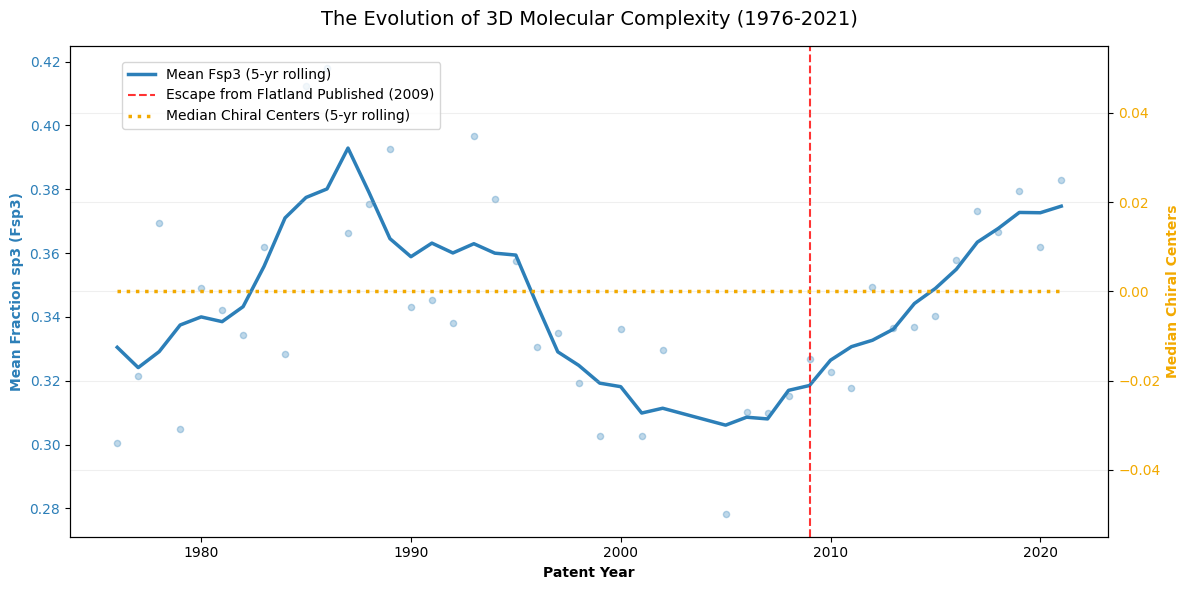

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Patent-year mapping and aggregation now live in the cell above - not repeated here.
# (The duplicate copy was how the stale-state bug stayed hidden: this cell silently
#  re-did the mapping correctly, so the plot looked fine while the earlier cell said nan.)

print("\n2. Running Hypothesis Tests...")
# Hypothesis 1: Did Fsp3 increase post-2009?
pre_2009 = flatland_df[flatland_df['patent_year'] <= 2009]['Fsp3'].dropna()
post_2009 = flatland_df[flatland_df['patent_year'] > 2009]['Fsp3'].dropna()

print("=== Hypothesis 1: The 'Escape from Flatland' Shift ===")
print(f"Median Fsp3 (Pre-2009):  {pre_2009.median():.4f}")
print(f"Median Fsp3 (Post-2009): {post_2009.median():.4f}")
stat, pval = stats.mannwhitneyu(pre_2009, post_2009)
print(f"Mann-Whitney U p-value:  {pval:.2e}")

# Hypothesis 2: Does 3D shape hurt yield or increase complexity?
print("\n=== Hypothesis 2: The Cost of 3D Space ===")
clean_tests = flatland_df.dropna(subset=['Fsp3', 'yield_pct_capped', 'complexity_score'])

r_yield, p_yield = stats.pearsonr(clean_tests['Fsp3'], clean_tests['yield_pct_capped'])
print(f"Fsp3 vs Yield:       r = {r_yield:.4f} (p = {p_yield:.2e})")

r_comp, p_comp = stats.pearsonr(clean_tests['Fsp3'], clean_tests['complexity_score'])
print(f"Fsp3 vs Complexity:  r = {r_comp:.4f}  (p = {p_comp:.2e})")


print("\n3. Plotting the 50-Year Trajectory...")
# Apply smoothing to the trendline
window = 5
smoothed = yearly_trends.set_index('patent_year').rolling(window, center=True, min_periods=3).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Fsp3
color1 = '#2c7fb8'
ax1.set_xlabel('Patent Year', fontweight='bold')
ax1.set_ylabel('Mean Fraction sp3 (Fsp3)', color=color1, fontweight='bold')
ax1.scatter(yearly_trends['patent_year'], yearly_trends['mean_Fsp3'], color=color1, alpha=0.3, s=20)
ax1.plot(smoothed.index, smoothed['mean_Fsp3'], color=color1, linewidth=2.5, label=f'Mean Fsp3 ({window}-yr rolling)')
ax1.tick_params(axis='y', labelcolor=color1)

# Highlight 2009 publication
ax1.axvline(2009, color='red', linestyle='--', alpha=0.8, linewidth=1.5, label='Escape from Flatland Published (2009)')

# Plot Chiral Centers on a secondary Y-axis
ax2 = ax1.twinx()  
color2 = '#f2a900'
ax2.set_ylabel('Median Chiral Centers', color=color2, fontweight='bold')  
ax2.plot(smoothed.index, smoothed['median_chiral'], color=color2, linewidth=2.5, linestyle=':', label=f'Median Chiral Centers ({window}-yr rolling)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('The Evolution of 3D Molecular Complexity (1976-2021)', fontsize=14, pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Where this lands

**What the numbers say:** Median Fsp3 moved from ~0.304 pre-2009 to ~0.333 post-2009. Real,
consistently signed, and small — about a 10% relative shift, or roughly one carbon in thirty
changing hybridisation on a typical molecule. The correlations with yield (r ≈ 0.07) and with
complexity (r ≈ 0.01) are statistically significant and practically negligible: at this n,
r = 0.01 is noise with a good publicist. If the "3D chemistry is harder to make" intuition is
true, it does not show up as a linear relationship at corpus scale.

Mildly interesting that the yield correlation is *positive* rather than negative. I'd been
expecting saturated targets to be the messier ones to get clean.

**Sources**

- Lovering, Bikker & Humblet (2009) *Escape from Flatland*, J. Med. Chem. 52(21), 6752–6756. [10.1021/jm901241e](https://doi.org/10.1021/jm901241e)
- Lovering (2013) *Escape from Flatland 2: complexity and promiscuity*, Med. Chem. Commun. 4, 515.
- Alvarado, Johnston & Brown, *Pharmaceutical manufacturing open datasets for machine learning in the primary and secondary domains*, CMAC / Univ. of Strathclyde, SSRN 6394198.
- USPTO, *Issue Years and Patent Numbers, Since 1836* — basis for the number → year crosswalk.
- Spärck Jones (1972) *A statistical interpretation of term specificity and its application in retrieval*, Journal of Documentation 28(1) — the IDF weighting used in the complexity score.
- RDKit `Descriptors.FractionCSP3`, `Chem.FindMolChiralCenters` — rdkit.org/docs
